<a href="https://colab.research.google.com/github/owlmt/QuantumSecurity/blob/main/Grover_Hash_Preimage_Optimal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The Best Quantum Algorithm for Hash Preimage — Grover (and why it's optimal) on Aer

A preimage attack: given a digest $d^\*$, find any $x$ with $H(x)=d^\*$. Unlike *collision* finding
(where BHT's $2^{n/3}$ beats naive search), for **preimage** the best quantum algorithm is simply
**Grover**, at $O(2^{n/2})$ — and it is *provably optimal*: the **BBBV** theorem (Bennett, Bernstein,
Brassard, Vazirani 1997) shows no quantum algorithm inverts an unstructured function in fewer than
$\Omega(2^{n/2})$ queries. So there is nothing better to show; there is only Grover, done right.

This notebook demonstrates three things on a toy hash:
1. **Textbook Grover** with a known number of preimages $M$ (optimal iteration count).
2. **BBHT** (Boyer–Brassard–Høyer–Tapp 1998) — the realistic case where $M$ is *unknown*, which is
   what an actual attacker faces.
3. The **optimality / scaling** picture, and how preimage differs from collision.

> **Honesty.** Grover is only a *quadratic* speedup. A SHA-256 preimage is $\sim2^{128}$ Grover
> iterations on thousands of fault-tolerant qubits — infeasible. This toy shows the mechanism only.

In [1]:
# Colab setup
!pip install -q qiskit qiskit-aer pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 79.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 95.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 75.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.8 MB/s eta 0:00:00


## 1. A toy hash and a target digest

Same compressing hash $H:\{0,1\}^{10}\to\{0,1\}^{6}$ as before. We take a secret message $s$,
publish only its digest $d^\*=H(s)$, and ask Grover to find *some* preimage (which may be $s$
itself or any other input hashing to $d^\*$).

In [2]:
import numpy as np, math, random, time
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit.library import UnitaryGate, ZGate
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

M_IN, N_OUT = 10, 6
N = 2**M_IN
rng = np.random.default_rng(7)
SBOX = list(rng.permutation(2**N_OUT))
def rotl(v, n=N_OUT): return ((v<<1)|(v>>(n-1))) & (2**n-1)
def H(x):
    xL=x&0x3F; xH=(x>>6)&0xF
    o=SBOX[xL]; o=SBOX[o^xH]; o=rotl(o); o=SBOX[o^(xL&0xF)]
    return o

secret = 0b1011000110
d_star = H(secret)
preimages = [x for x in range(N) if H(x)==d_star]
M = len(preimages)
print(f"secret message s = {secret:0{M_IN}b}")
print(f"published digest d* = H(s) = {d_star:0{N_OUT}b}")
print(f"# preimages of d*: M = {M}   (attacker does NOT know this)")
print(f"classical preimage search ~ N/M = {N/M:.0f} hash calls")
print(f"quantum (Grover)         ~ sqrt(N/M) = {math.sqrt(N/M):.1f} oracle calls")

secret message s = 1011000110
published digest d* = H(s) = 101011
# preimages of d*: M = 14   (attacker does NOT know this)
classical preimage search ~ N/M = 73 hash calls
quantum (Grover)         ~ sqrt(N/M) = 8.6 oracle calls


## 2. Reversible hash, oracle, diffuser

The oracle marks $\{x: H(x)=d^\*\}$ by computing $H$ into an ancilla, phase-flipping the digest
$d^\*$, and uncomputing. We verify the quantum hash against the classical one first.

In [3]:
def perm_gate(table, label):
    Mx=np.zeros((2**N_OUT,2**N_OUT))
    for v,o in enumerate(table): Mx[o,v]=1
    return UnitaryGate(Mx, label=label)
SG=perm_gate(SBOX,"S"); RG=perm_gate([rotl(v) for v in range(2**N_OUT)],"rot")

def hash_circuit(xin,out):
    c=QuantumCircuit(xin,out,name="H")
    for i in range(6): c.cx(xin[i],out[i])
    c.append(SG,out[:])
    for i in range(4): c.cx(xin[6+i],out[i])
    c.append(SG,out[:]); c.append(RG,out[:])
    for i in range(4): c.cx(xin[i],out[i])
    c.append(SG,out[:])
    return c

def mcz(c,qs,val,w):
    for i in range(w):
        if not ((val>>i)&1): c.x(qs[i])
    c.append(ZGate().control(w-1),qs[:])
    for i in range(w):
        if not ((val>>i)&1): c.x(qs[i])

def oracle_gate():
    xin=QuantumRegister(M_IN,'x'); out=QuantumRegister(N_OUT,'o')
    c=QuantumCircuit(xin,out,name="Oracle")
    Hg=hash_circuit(xin,out).to_gate()
    c.append(Hg,xin[:]+out[:]); mcz(c,out,d_star,N_OUT); c.append(Hg.inverse(),xin[:]+out[:])
    return c
def diffuser_gate():
    xin=QuantumRegister(M_IN,'x'); c=QuantumCircuit(xin,name="Diffuser")
    c.h(xin); c.x(xin); c.append(ZGate().control(M_IN-1),xin[:]); c.x(xin); c.h(xin)
    return c

sim=AerSimulator()
xin=QuantumRegister(M_IN,'x'); out=QuantumRegister(N_OUT,'o')
ok=True
for xt in rng.choice(N,24,replace=False):
    t=QuantumCircuit(xin,out)
    for i in range(M_IN):
        if (int(xt)>>i)&1: t.x(xin[i])
    t.compose(hash_circuit(xin,out),inplace=True); t.save_statevector()
    sv=sim.run(t).result().get_statevector()
    ok &= (((int(np.argmax(np.abs(sv.data)))>>M_IN)&(2**N_OUT-1))==H(int(xt)))
print("quantum hash matches classical:", ok)

O=oracle_gate().to_gate(); D=diffuser_gate().to_gate()
def grover_circuit(j, measure=True):
    x=QuantumRegister(M_IN,'x'); o=QuantumRegister(N_OUT,'o'); cl=ClassicalRegister(M_IN,'m')
    qc=QuantumCircuit(x,o,cl); qc.h(x)
    for _ in range(j):
        qc.append(O,x[:]+o[:]); qc.append(D,x[:])
    if measure: qc.measure(x,cl)
    return qc

quantum hash matches classical: True


## 3. Textbook Grover — known $M$

When $M$ is known, the optimal iteration count is $\big\lfloor \frac{\pi}{4}\sqrt{N/M}\big\rceil$.

iterations = 7,  P(valid preimage) = 0.963
found x = 1101001011   H(x) = 101011   valid preimage: True
(is it the original secret? False -- any preimage is a valid answer)


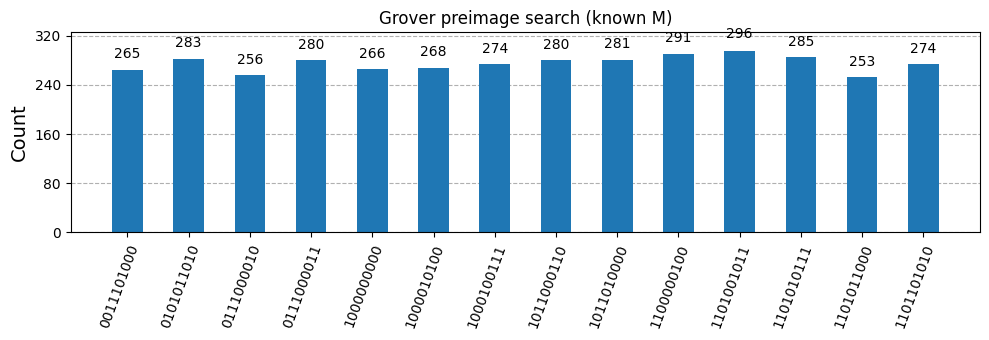

In [4]:
iters = round(math.pi/4*math.sqrt(N/M))
qc = grover_circuit(iters)
counts = sim.run(transpile(qc,sim),shots=4000).result().get_counts()
tot=sum(counts.values())
succ=sum(c for bs,c in counts.items() if H(int(bs,2))==d_star)
best=int(max(counts,key=counts.get),2)
print(f"iterations = {iters},  P(valid preimage) = {succ/tot:.3f}")
print(f"found x = {best:0{M_IN}b}   H(x) = {H(best):0{N_OUT}b}   valid preimage: {H(best)==d_star}")
print(f"(is it the original secret? {best==secret} -- any preimage is a valid answer)")
plot_histogram({k:v for k,v in sorted(counts.items(),key=lambda kv:-kv[1])[:14]},
               figsize=(10,3.5), title='Grover preimage search (known M)')

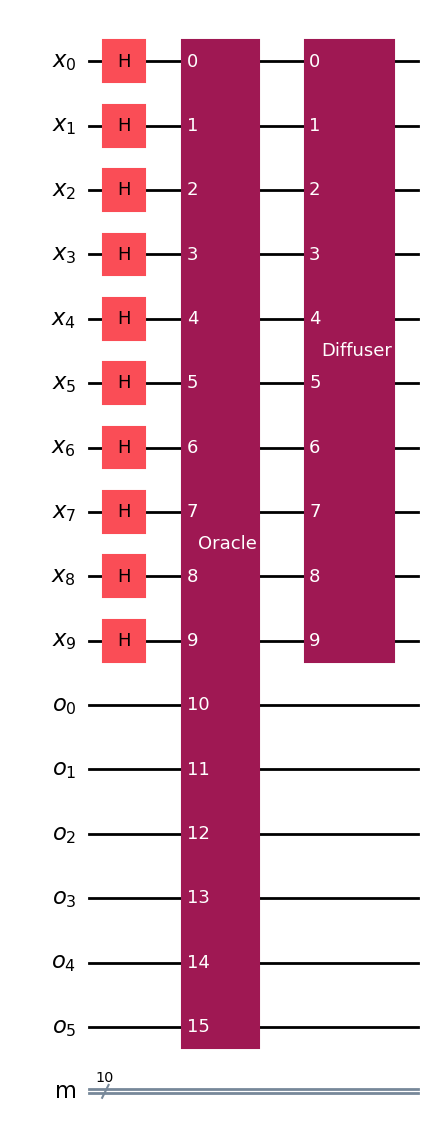

In [5]:
grover_circuit(1, measure=False).draw('mpl', fold=-1)  # one Grover iteration, drawn

## 4. The realistic case — $M$ unknown: BBHT

A real attacker doesn't know how many preimages the target has, so they can't pick the right
iteration count (too many *overshoots* and de-amplifies). **BBHT** solves this with a randomized,
geometrically growing schedule and still achieves expected $O(\sqrt{N/M})$:

1. start with budget $m=1$;
2. pick $j$ uniformly in $[0,m)$, run $j$ Grover iterations, measure $x$;
3. if $H(x)=d^\*$ stop, else grow $m \leftarrow \min(\lambda m,\sqrt N)$ with $\lambda=6/5$.

(The alternative is **quantum counting** — phase estimation on the Grover operator — to estimate
$M$ first, then run optimal Grover. BBHT avoids that overhead.)

In [6]:
random.seed(1)
lam, m_sched, total_oracle_calls, found, trials = 6/5, 1.0, 0, None, 0
log=[]
while found is None and trials < 80:
    trials += 1
    j = random.randint(0, max(0, int(math.ceil(m_sched)) - 1))
    bs = list(sim.run(transpile(grover_circuit(j),sim), shots=1).result().get_counts())[0]
    x = int(bs, 2)
    total_oracle_calls += max(j, 1)
    hit = (H(x) == d_star)
    log.append((trials, j, x, hit))
    if hit: found = x
    else:   m_sched = min(lam*m_sched, math.sqrt(N))

print("trial   j   measured x      H(x)     hit?")
for tr,j,x,hit in log:
    print(f"  {tr:>3}  {j:>3}   {x:0{M_IN}b}   {H(x):0{N_OUT}b}    {'YES' if hit else 'no'}")
print(f"\nPREIMAGE FOUND: x = {found:0{M_IN}b}, H(x) = {H(found):0{N_OUT}b}")
print(f"total Grover oracle calls = {total_oracle_calls}   "
      f"(classical expected ~ {round(N/M)}; speedup ~{(N/M)/max(total_oracle_calls,1):.1f}x)")

trial   j   measured x      H(x)     hit?
    1    0   1000100101   000101    no
    2    0   1110110000   011001    no
    3    1   1001010101   010000    no
    4    0   1011111110   010100    no
    5    1   1000101110   100010    no
    6    1   0011000001   000010    no
    7    1   1110111001   001110    no
    8    3   1010000000   010001    no
    9    1   0101111010   000111    no
   10    0   1001111111   101100    no
   11    3   1101001011   101011    YES

PREIMAGE FOUND: x = 1101001011, H(x) = 101011
total Grover oracle calls = 15   (classical expected ~ 73; speedup ~4.9x)


## 5. Optimality and scaling

Grover is the *whole story* for preimage: by the **BBBV** lower bound it is optimal up to constants,
so $2^{n/2}$ is the best any quantum computer can do against a generic $n$-bit preimage. The dent is
real but only quadratic.

In [7]:
print(f"{'target':18s}{'preimage bits':>14}{'classical 2^n':>16}{'quantum 2^(n/2)':>17}{'feasible':>11}")
for name,n in [("toy hash",6),("SHA-1",160),("SHA-256",256),("SHA-512",512)]:
    print(f"{name:18s}{n:>14}{('2^%d'%n):>16}{('2^%d'%(n//2)):>17}{('yes' if n<=16 else 'NO'):>11}")
print("\npreimage : Grover, 2^(n/2), provably OPTIMAL (BBBV).")
print("collision: BHT,    2^(n/3), but needs ~2^(n/3) QRAM -> little practical gain.")
print("=> doubling the digest length restores the pre-quantum security margin.")

target             preimage bits   classical 2^n  quantum 2^(n/2)   feasible
toy hash                       6             2^6              2^3        yes
SHA-1                        160           2^160             2^80         NO
SHA-256                      256           2^256            2^128         NO
SHA-512                      512           2^512            2^256         NO

preimage : Grover, 2^(n/2), provably OPTIMAL (BBBV).
collision: BHT,    2^(n/3), but needs ~2^(n/3) QRAM -> little practical gain.
=> doubling the digest length restores the pre-quantum security margin.


### Notes

- **Is this BHT?** No — and neither was the collision notebook. That one ran *single-anchor Grover*
  (a second-preimage search); BHT is the table-based generalization. This notebook is likewise
  Grover, which for *preimage* is exactly the best/optimal algorithm, so the labelling is accurate
  here.
- **Why both Grover variants matter.** Section 3 is the idealized textbook version; Section 4 (BBHT)
  is what you would actually run, since the preimage count is unknown in practice.
- **Experiment.** Change `secret`, the S-box seed, or widen `M_IN`/`N_OUT`. Past ~26–28 qubits the
  statevector no longer fits in memory — the same wall protecting real hashes.